# Case1: Huizenprijzen
**Data Science 2025-2026| numpy & matplotlib**

---

In deze notebook zal je numPy gebruiken om:

1. Een **synthetische dataset** te genereren en steekproeven te trekken
2. **Uitschieters of outliers** te detecteren via de  Z-score methode en IQR-methode
3. **Data te transformeren** 
4. Te rekenen via **broadcasting** 

**Context:** je werkt met een gesimuleerde dataset van huizenprijzen in een fictieve stad.  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)
print(f"NumPy versie: {np.__version__} ✓")

NumPy versie: 2.4.4 ✓


---
## Deel 1 – Reproduceerbare willekeurige data

Synthetische data is onmisbaar in EDA: je gebruikt het om methodes te testen,  
verdelingen te simuleren en steekproeven te vergelijken.

### 1.1 – Seed en reproduceerbaarheid

Zonder seed geeft elke run andere getallen. Met `np.random.seed()` fixeer je de uitvoer —  
essentieel voor deelbare en reproduceerbare analyses.

**1.1a:** Genereer twee keer 5 willekeurige getallen **zonder** seed. Zijn ze gelijk?  
**1.1b:** Doe hetzelfde **met** `np.random.seed(42)` vóór elke aanroep. Zijn ze nu gelijk?

In [ ]:
# 1.1
print(np.random.random(5))
print(np.random.random(5))

[0.29 0.6  0.71 0.27 0.94]
[0.46 0.61 0.52 0.34 0.43]


In [ ]:
# 1.2
np.random.seed(42)
print(np.random.random(5))
np.random.seed(42)
print(np.random.random(5))

[0.37 0.95 0.73 0.6  0.16]
[0.37 0.95 0.73 0.6  0.16]


### 1.2 – Dataset genereren: huizenprijzen

Genereer een realistische dataset van **500 huizenprijzen** (in €1000):  
- De meeste prijzen volgen een **normale verdeling** rond €280.000 (std = €60.000)
- We voegen **10 extreme uitschieters** toe (zeer dure villa's: €800.000–€1.200.000)
- We voegen **5 negatieve fouten** toe (datakwaliteitsproblemen)

> Tip: Genereer apart de normale voorbeelden, de uitschieters en de negatieve voorbeelden. Bouw de volledige array `prijzen` op via `np.concatenate()`.

In [ ]:
np.random.seed(3)
normal = np.random.normal(280_000, 60_000, 500)

np.random.seed(3)
outliers = np.random.uniform(800_000, 1_200_000, 10)

np.random.seed(3)
negative = np.random.uniform(-340_000, -220_000, 5)

prices = np.concatenate([normal, outliers, negative])
prices = np.round(prices / 1000) * 1000

prices

array([ 387000.,  306000.,  286000.,  168000.,  263000.,  259000.,
        275000.,  242000.,  277000.,  251000.,  201000.,  333000.,
        333000.,  383000.,  283000.,  256000.,  247000.,  187000.,
        339000.,  214000.,  209000.,  268000.,  369000.,  294000.,
        219000.,  237000.,  318000.,  270000.,  234000.,  266000.,
        325000.,  399000.,  205000.,  242000.,  232000.,  135000.,
        225000.,  219000.,  347000.,  272000.,  183000.,  319000.,
        259000.,  175000.,  244000.,  245000.,  228000.,  282000.,
        145000.,  264000.,  341000.,  331000.,  346000.,  347000.,
        369000.,  213000.,  331000.,  168000.,  244000.,  165000.,
        343000.,  360000.,  268000.,  386000.,  240000.,  289000.,
        289000.,  216000.,  306000.,  396000.,  219000.,  334000.,
        271000.,  386000.,  309000.,  321000.,  319000.,  295000.,
        196000.,  363000.,  198000.,  294000.,  317000.,  230000.,
        289000.,  350000.,  279000.,  227000.,  105000.,  2220

### 1.3 – Steekproef trekken

Voor een kleinschalig onderzoek wil je een **willekeurige steekproef van 50 huizen** trekken  
**zonder terugleggen** (elk huis kan maar één keer geselecteerd worden).

**1.3a:** Trek de steekproef via `np.random.choice()`.  
**1.3b:** Vergelijk het gemiddelde van de steekproef met dat van de volledige dataset.  
**1.3c:** Trek 1000 steekproeven van 50 en bereken het gemiddelde van elk — dit is een **bootstrap-simulatie**. Wat is het gemiddelde van die 1000 gemiddelden?

> Tip: Voor de bootstrap kan je een list comprehension gebruiken (in combinatie met `np.random.choice` en `np.mean`)

In [ ]:
# 1.3a
np.random.seed(3)

sample = np.random.choice(prices, size=50)

In [ ]:
# 1.3b 
meanData = prices.mean()
meanSample = sample.mean()

print(f"Data: {meanData}, steekproef: {meanSample}")

Data: 288747.57281553396, steekproef: 321640.0


In [ ]:
# 1.3c 
# sample_mean = []
# for i in range(1000):
#   s = np.random.choice(prices, 50, replace=True)
#   sample_mean.append(np.mean(s))

sample_mean = np.array([np.mean(np.random.choice(prices, size=50, replace=False)) for _ in range(1000)])

# sample_mean = np.array(sample_mean)
print(sample_mean.mean())

288915.5


---
## Deel 2 – Uitschieterdetectie

Uitschieters kunnen berekeningen ernstig vertekenen. We bekijken twee methodes.

### 2.1 – Z-score methode

De Z-score meet hoeveel standaardafwijkingen een waarde van het gemiddelde afwijkt:

$$z_i = \frac{x_i - \mu}{\sigma}$$

Waarden met $|z| > 3$ worden als uitschieter beschouwd.

**2.1a:** Bereken de Z-scores van alle `prijzen`.  
**2.1b:** Maak een boolean masker `masker_z` voor uitschieters ($|z| > 3$).  
**2.1c:** Hoeveel uitschieters zijn er? Wat zijn de waarden?  
**2.1d:** Maak `prijzen_clean_z`: de array **zonder** die uitschieters.

> Tip: `~masker` keert een boolean masker om — handig om de niet-uitschieters te selecteren.

In [ ]:
# 2.1a
z_scores = (prices - np.mean(prices)) / np.std(prices)

# 2.1b
masker_z = np.abs(z_scores) > 3

# 2.1c
outliers = z_scores[masker_z]
print(len(outliers))
print(outliers)

# print(masker_z.sum())
# print(np.sort(prices[masker_z])) in de les

# 2.1d
prijzen_clean_z = z_scores[~masker_z]

print(prijzen_clean_z)

15
[ 5.7   6.19  4.89  5.57  6.76  6.78  4.37  4.63  4.15  5.35 -4.38 -4.24
 -4.63 -4.42 -4.07]
[ 0.77  0.13 -0.02 -0.94 -0.2  -0.23 -0.11 -0.36 -0.09 -0.29 -0.68  0.34
  0.34  0.73 -0.04 -0.26 -0.33 -0.79  0.39 -0.58 -0.62 -0.16  0.63  0.04
 -0.54 -0.4   0.23 -0.15 -0.43 -0.18  0.28  0.86 -0.65 -0.36 -0.44 -1.2
 -0.5  -0.54  0.45 -0.13 -0.82  0.24 -0.23 -0.89 -0.35 -0.34 -0.47 -0.05
 -1.12 -0.19  0.41  0.33  0.45  0.45  0.63 -0.59  0.33 -0.94 -0.35 -0.96
  0.42  0.56 -0.16  0.76 -0.38  0.    0.   -0.57  0.13  0.84 -0.54  0.35
 -0.14  0.76  0.16  0.25  0.24  0.05 -0.72  0.58 -0.71  0.04  0.22 -0.46
  0.    0.48 -0.08 -0.48 -1.43 -0.52 -0.34 -0.31 -0.52  0.11 -0.33 -0.12
  0.25 -0.47 -0.21  0.94  0.34 -0.68 -0.11  0.2   0.51  0.   -0.32 -0.41
  0.24  0.08 -0.31 -0.15 -0.26  0.27 -0.39  0.16  0.33  0.16 -0.46  0.56
 -0.39  0.13 -0.42 -0.89  0.04  0.06 -0.11  0.06 -0.37 -0.41 -0.15  0.83
  0.31 -0.31  0.2  -0.29 -0.28  0.34 -0.32 -0.86 -0.49 -0.03 -0.01  0.51
 -0.4   0.27  0.13 -0.14  0.3

### 2.2 – IQR-methode

De IQR-methode is robuuster dan Z-scores omdat ze niet gevoelig is voor het gemiddelde (dat zelf al beïnvloed kan zijn door uitschieters).

Een waarde is een uitschieter als:
$$x < Q1 - 1.5 \times IQR \quad \text{of} \quad x > Q3 + 1.5 \times IQR$$

**2.2a:** Bereken Q1, Q3 en IQR via `np.percentile()`.  
**2.2b:** Bereken de onder- en bovengrens.  
**2.2c:** Maak masker `masker_iqr` en de schone dataset `prijzen_clean_iqr`.  
**2.2d:** Vergelijk het aantal uitschieters gevonden door Z-score vs. IQR. Welke methode is strenger?

In [ ]:

# 2.2a
Q1 = np.percentile(prices, 25)
Q3 = np.percentile(prices, 75)
IQR = Q3 - Q1

# 2.2b
ondergrens = Q1 - 1.5 * IQR
bovengrens = Q3 + 1.5 * IQR

# 2.2c
masker_iqr = (prices > bovengrens) | (prices < ondergrens)
prijzen_clean_iqr = prices[~masker_iqr]

# 2.2d
print((~masker_z).sum())
print((~masker_iqr).sum())
# IQR-methode is strenger.

500
498


### 2.3 – Visualisatie: Z-score vs. IQR

Maak een figuur met **twee subplots naast elkaar**:  
- Links: histogram van alle `prijzen` met de IQR-grenzen aangeduid als verticale lijnen  
- Rechts: scatter van de Z-scores, met een horizontale lijn op +3 en −3; kleur niet-uitschieters in blauw en uitschieters in rood via twee aparte `ax.scatter()` aanroepen.

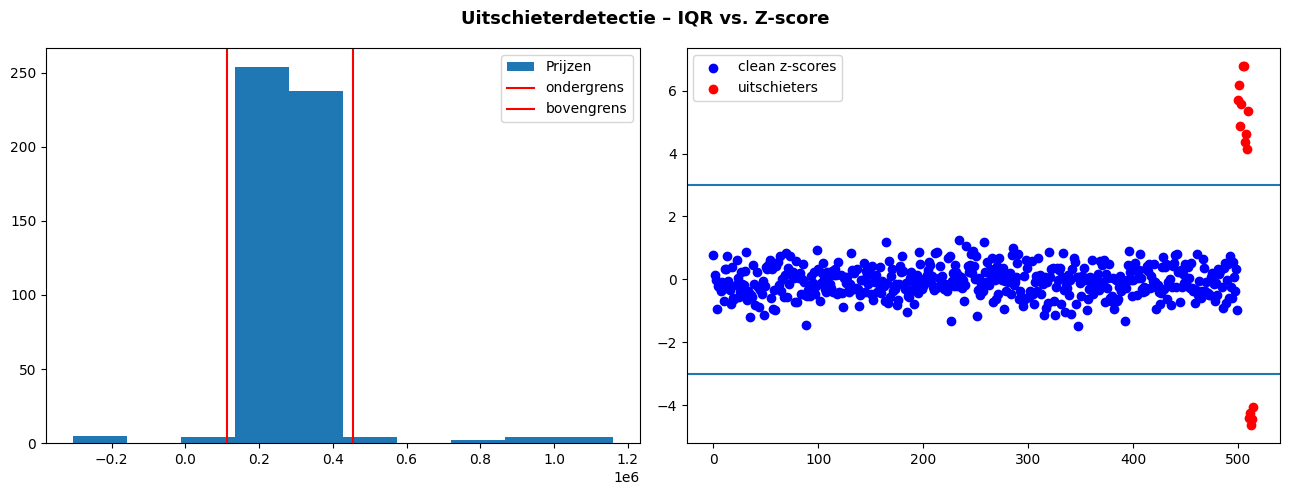

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# JOUW CODE HIER
ax1.hist(prices, label="Prijzen")
ax1.axvline(ondergrens, label="ondergrens", color="red")
ax1.axvline(bovengrens, label="bovengrens", color="red")
ax1.legend()

# ax2.scatter(z_scores, np.zeros(len(z_scores)), label="z-scores")
indices = np.arange(len(prices))
ax2.scatter(indices[~masker_z], prijzen_clean_z, label="clean z-scores", color="blue")
ax2.scatter(indices[masker_z], outliers, label="uitschieters", color="red")
ax2.axhline(3)
ax2.axhline(-3)
ax2.legend()

fig.suptitle("Uitschieterdetectie – IQR vs. Z-score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Deel 3 – Transformaties

We werken verder met `prijzen_clean_iqr` — de dataset na IQR-filtering.

### 3.1 – Log-transformatie

Huizenprijzen zijn vaak **rechts-scheef** verdeeld: veel goedkope huizen, weinig dure.  
Een log-transformatie maakt zo'n verdeling symmetrischer — een vereiste voor veel statistische methodes.

**3.1a:** Controleer de scheefheid vóór transformatie: bereken `gemiddelde - mediaan` op `prijzen_clean_iqr`.  
Een positief verschil wijst op rechtse scheefheid.

**3.1b:** Pas `np.log()` toe. Waarom kan dit problemen geven? Gebruik `np.log1p()` als alternatief.

**3.1c:** Bereken opnieuw `gemiddelde - mediaan` op de log-getransformeerde data. Is de verdeling symmetrischer geworden?

>  `np.log1p(x)` berekent $\ln(1 + x)$ — veilig voor waarden dicht bij 0.

**3.1d:** Maak een figuur met **twee histogrammen naast elkaar**:
- Links: originele `prijzen_clean_iqr` — duid het gemiddelde en de mediaan aan
- Rechts: log-getransformeerde `log_data` — duid eveneens gemiddelde en mediaan aan

Wat valt je op aan het verschil tussen gemiddelde en mediaan vóór en na de transformatie?

In [ ]:
# 3.1a
scheefheid_voor = np.mean(prijzen_clean_iqr) - np.median(prijzen_clean_iqr)
# Positief getal => rechtse scheefheid
print(scheefheid_voor)

# 3.1b
# print(np.log(prijzen_clean_iqr))
# Het zou kunnen negatief zijn en dan werkt het niet.
log_data = np.log1p(prijzen_clean_iqr)

# 3.1c
scheefheid_na = np.mean(log_data) - np.median(log_data)
print(scheefheid_na)
# Ja, de verdeling is symmetrischer geworden.

3076.3052208835143
-0.013613155061049653


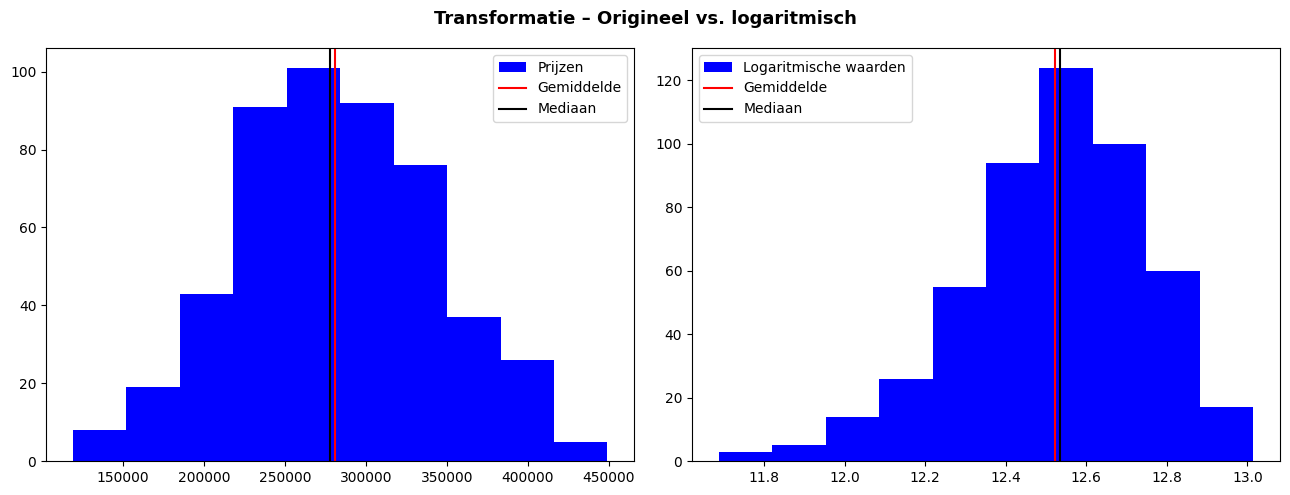

In [ ]:
# 3.1d
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Code hier
ax1.hist(prijzen_clean_iqr, label="Prijzen", color="blue")
ax1.axvline(np.mean(prijzen_clean_iqr), label="Gemiddelde", color="red")
ax1.axvline(np.median(prijzen_clean_iqr), label="Mediaan", color="black")
ax1.legend()

ax2.hist(log_data, label="Logaritmische waarden", color="blue")
ax2.axvline(np.mean(log_data), label="Gemiddelde", color="red")
ax2.axvline(np.median(log_data), label="Mediaan", color="black")
ax2.legend()

fig.suptitle("Transformatie – Origineel vs. logaritmisch", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# In het begin was het verschil positief, na de transformatie is de mediaan groter en dus is het verschil negatief.

### 3.2 – Clip: extreme waarden begrenzen

Soms wil je uitschieters **niet verwijderen** maar **begrenzen** — bv. om te voorkomen dat één datapunt  
een heel model domineert, terwijl je toch alle rijen behoudt.

**3.2a:** Clip de originele `prijzen`-array zodat alle waarden tussen €50k en €600k vallen via `np.clip()`.  
**3.2b:** Hoeveel waarden werden effectief aangepast (waren buiten de grenzen)?  
**3.2c:** Vergelijk het gemiddelde vóór en na clipping.

>  `np.clip(array, a_min, a_max)` — waarden onder `a_min` worden `a_min`, waarden boven `a_max` worden `a_max`.

In [ ]:
# 3.2a
# np.clip(array, min, max)
clipped_prices = np.clip(prices, 50_000, 600_000)

# 3.2b
aangepast = np.sum(prices != clipped_prices)
print(aangepast)  # 15

# 3.2c
print(np.mean(prices))
print(np.mean(clipped_prices))

15
288747.57281553396
284333.98058252427


### 3.3 – np.where(): conditionele hercodering

`np.where(conditie, waarde_als_True, waarde_als_False)` is de vectoriële versie van een if-else —  
veel sneller dan een Python-lus of pandas `.apply()`.

**3.3a:** Maak een array `categorie` op basis van `prijzen_clean_iqr`:  
- `"duur"` als de prijs **boven** het 75ste percentiel ligt  
- `"goedkoop"` anders  

**3.3b:** Hoeveel huizen zijn "duur"? Wat is het gemiddelde van elk segment?

>  Je kan `np.where()` ook **nesten** voor meer dan twee categorieën:  
> `np.where(cond1, 'A', np.where(cond2, 'B', 'C'))`

In [ ]:
# 3.3a
categorie = np.where(prijzen_clean_iqr > Q3, "duur", "goedkoop")

# 3.3b
duur = categorie == "duur"
print(f"Er zijn {len(categorie[duur])} dure huizen.")
print(f"De gemiddelden:\n Dure huizen: {np.mean(prijzen_clean_iqr[duur])}\n Goedkope huizen: {np.mean(prijzen_clean_iqr[~duur])}")

Er zijn 119 dure huizen.
De gemiddelden:
 Dure huizen: 361411.76470588235
 Goedkope huizen: 255852.24274406332


---
## Deel 4 – Broadcasting in EDA

Broadcasting laat je bewerkingen uitvoeren op arrays met **verschillende vormen** zonder lussen.  
In EDA duikt dit op zodra je berekeningen wil doen **per groep** — bv. per wijk, per categorie, per sensor.

De kernregel: twee dimensies zijn compatibel als ze gelijk zijn, of als één van beide **1** is.  
Een vector van vorm `(5,)` pas je toe op een matrix van vorm `(5, 100)` door te reshapen naar `(5, 1)`.

### 4.1 – Normalisatie per wijk

We simuleren een matrix `wijk_prijzen` van **5 wijken × 100 huizen** (vorm: `(5, 100)`).  


In [ ]:
np.random.seed(42)
# Elke wijk heeft een ander basisniveau (200k t.e.m. 600k)
basisniveaus = np.array([200, 280, 350, 450, 580])
wijk_prijzen = basisniveaus.reshape(-1, 1) + np.random.normal(0, 40, size=(5, 100))

Elke wijk heeft een eigen prijsniveau. We willen de prijzen **per wijk normaliseren**:  
elke prijs gedeeld door het wijkgemiddelde, zodat een waarde van 1.0 = precies het wijkgemiddelde.

**4.1a:** Bereken het gemiddelde per wijk — `gem_per_wijk` heeft vorm `(5,)`.  
**4.1b:** Normaliseer `wijk_prijzen` door te delen door `gem_per_wijk` **zonder lus**.  

> **Tip:** `gem_per_wijk` heeft vorm `(5,)` maar `wijk_prijzen` heeft vorm `(5, 100)` — dat klopt niet direct.  
> Reshape naar `(5, 1)` zodat broadcasting de deling toepast op elke kolom.

In [ ]:
# 4.1a
gem_per_wijk = wijk_prijzen.mean(axis=1)
print(gem_per_wijk.astype(int))

# 4.1b
normalizering = wijk_prijzen / gem_per_wijk.reshape(5,1) # reshape(-1, 1)
normalizering.mean(axis=1)

[195 280 352 454 577]


array([1., 1., 1., 1., 1.])

### 4.2 – Z-scores per wijk

In de vorige notebook berekenden we Z-scores over de **volledige dataset**.  
Maar een huis van €350k is goedkoop in wijk 5 (gem. €580k) en duur in wijk 1 (gem. €200k).  
Correcte uitschieterdetectie vereist Z-scores **per wijk**.

**4.2a:** Bereken de standaardafwijking per wijk — `std_per_wijk` heeft vorm `(5,)`.  
**4.2b:** Bereken de Z-scores per wijk via broadcasting (geen lus).  
**4.2c:** Tel per wijk het aantal uitschieters ($|z| > 2$).

In [ ]:
# 4.2a
std_per_wijk = wijk_prijzen.std(axis=1)

# 4.2b
z_scores2 = (wijk_prijzen - wijk_prijzen.mean(axis=1).reshape(5,1)) / std_per_wijk.reshape(5,1)

# 4.2c
uitschieters_per_wijk = (np.abs(z_scores2) > 2).sum(axis=1)
print(uitschieters_per_wijk)

[5 4 3 6 2]
